In [1]:
include("SystemResponses.jl")
include("SymolicDerivative.jl")

using DifferentialEquations, SymbolicRegression, Logging, Interpolations
using .SymbolicDerivativeModule

In [9]:
binary_operators=(+, *, -, /)
unary_operators=(cos, sin, exp)

options = SymbolicRegression.Options(;
    binary_operators=binary_operators, 
    unary_operators=unary_operators,
    seed=42,
    # output_directory="output/deriv_search" # Save results to this file
)

# Define operators
operators = OperatorEnum(
    binary_operators=binary_operators,
    unary_operators=unary_operators
)

variable_names = ["x1", "x2", "x3"]

# Define variables (feature 2 is x2, feature 3 is x3)
x2 = Expression(Node{Float64}(feature=2); operators, variable_names)
x3 = Expression(Node{Float64}(feature=3); operators, variable_names)

# Construct the expression: -2 * x2 + 0.5 * x3
expression = -2.0 * x2 + 0.5 * x3
func1 = (-4.1941 * x2) + x3
func2 = (x3 * 0.21562) - x2
wrong_function = 3.0 * x2 - x3 + 5.0

# Test evaluation
X = randn(Float64, 3, 100)
output = expression(X)

println("Expression: ", expression)
println("Result: ", result)

Expression: (-2.0 * x2) + (0.5 * x3)
Result: (-4.1941 * x2) + x3


In [3]:
t = 0:0.1:10
u = sin.(t) # control input
x = SystemResponsesModule.linear_controlled_system_response(t, u; a=2.0, b=0.5, error_std=0.0);
t_x_u = vcat(t', x', u')

dataset = Dataset(t_x_u, x);

In [4]:
# For a single point [1, 2, 3]
input = reshape([1.0, 2.0, 3.0], :, 1)  # Creates a 3x1 matrix
expression(input)

1-element Vector{Float64}:
 -2.5

In [5]:
function l2_loss_ocp(tree, dataset, options)
    # Extract time points, states, and control inputs from dataset
    # Assuming dataset.X has rows: [t; x; u]
    t = dataset.X[1, :]  # time points
    x_actual = dataset.X[2, :]  # actual state trajectory
    u = dataset.X[3, :]  # control input
    
    # Initial condition
    x0 = x_actual[1]
    tspan = (t[1], t[end])
    
    # Create interpolation for control input
    u_interp = LinearInterpolation(t, u)
    
    # Define ODE function: dx/dt = tree([t, x, u])
    function ocp_dynamics(x, p, t_curr)
        # Get control input at current time
        u_curr = u_interp(t_curr)
        
        # Create input vector [t, x, u] for the tree (matching 3 features)
        input = reshape([t_curr, x, u_curr], :, 1)
        
        # Evaluate tree to get dx/dt
        dx = tree(input)[1]
        
        return dx
    end
    
    # Solve the ODE
    ode_problem = ODEProblem(ocp_dynamics, x0, tspan)
    solution = solve(
        ode_problem,
        AutoTsit5(Rosenbrock23()),
        maxiters=5000,
        saveat=t,
        abstol=1e-3,
        reltol=1e-3,
        verbose=0
    )
    
    # Calculate loss
    if SciMLBase.successful_retcode(solution) && length(solution.u) == length(x_actual)
        x_predicted = [solution.u[i] for i in 1:length(solution.u)]
        loss = sum((x_predicted .- x_actual).^2) / length(x_actual)
    else
        loss = Inf
    end
    
    return loss
end

l2_loss_ocp(expression, dataset, "")

1.2848138010667818e-5

In [11]:
println(l2_loss_ocp(expression, dataset, ""))
println(l2_loss_ocp(wrong_function, dataset, ""))
println(l2_loss_ocp(func1, dataset, ""))
println(l2_loss_ocp(func2, dataset, ""))

1.2848138010667818e-5
6.120702042491991e24
0.0013623144147469819
0.0037705024265663072


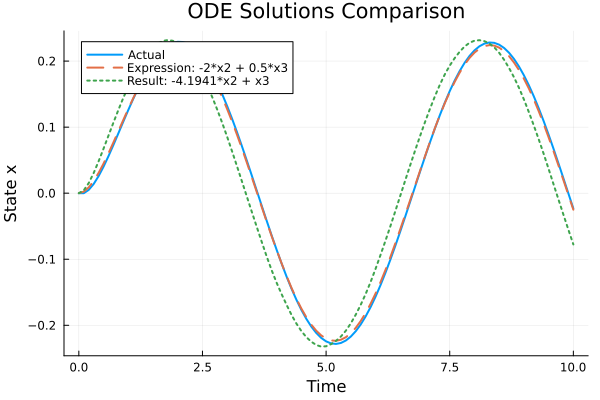

In [8]:
using Plots

# Solve ODE for each expression
function solve_ocp(tree, dataset)
    t = dataset.X[1, :]
    x_actual = dataset.X[2, :]
    u = dataset.X[3, :]
    x0 = x_actual[1]
    tspan = (t[1], t[end])
    u_interp = LinearInterpolation(t, u)
    
    function ocp_dynamics(x, p, t_curr)
        u_curr = u_interp(t_curr)
        input = reshape([t_curr, x, u_curr], :, 1)
        dx = tree(input)[1]
        return dx
    end
    
    ode_problem = ODEProblem(ocp_dynamics, x0, tspan)
    solution = solve(ode_problem, AutoTsit5(Rosenbrock23()), 
                     maxiters=5000, saveat=t, abstol=1e-3, reltol=1e-3, verbose=0)
    
    return solution.u
end

# Get solutions
t = dataset.X[1, :]
x_actual = dataset.X[2, :]
x_expression = solve_ocp(expression.tree, dataset)
x_result = solve_ocp(result.tree, dataset)
# x_wrong = solve_ocp(wrong_function.tree, dataset)

# Create plot
plot(t, x_actual, label="Actual", linewidth=2, legend=:topleft)
plot!(t, x_expression, label="Expression: -2*x2 + 0.5*x3", linestyle=:dash, linewidth=2)
plot!(t, x_result, label="Result: -4.1941*x2 + x3", linestyle=:dot, linewidth=2)
# plot!(t, x_wrong, label="Wrong: 3*x2 - x3 + 5", linestyle=:dashdot, linewidth=2)
xlabel!("Time")
ylabel!("State x")
title!("ODE Solutions Comparison")